# Imports

In [1]:
# General util imports
import os

import tkinter as tk
from tkinter import filedialog

# Math and ML imports
import torch
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

# Visualization imports
from matplotlib import pyplot as plt
from matplotlib import patches
from matplotlib.lines import Line2D
from tqdm import tqdm

# Custom imports
from util import download_dataset, create_dataframes, pair_images
from custom_datasets import CBISDDSM_RCNN_Dataset

# Kaggle setup and dataset download

In [2]:
download_dataset()

Path to dataset files: C:\Users\nerfb\.cache\kagglehub\datasets\awsaf49\cbis-ddsm-breast-cancer-image-dataset\versions\1
Target directory is not empty. Skipping data copy.


# Create dataframes

In [3]:
df, full_mammograms_df, roi_masks_df, _ = create_dataframes()

print(f"Total ROIs: {len(roi_masks_df)}")
print(roi_masks_df['image_path'].head(5))

Total ROIs: 1696
5     ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
10    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
12    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
18    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
19    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
Name: image_path, dtype: str


# Pair ROIs with full images

In [4]:
paired_df, merged_df = pair_images(roi_masks_df, full_mammograms_df)

Successfully paired 1696 mammogram/ROI pairs.
Removed 78 entries due to mismatched dimensions.
Consolidated into 1514 image entries.


In [5]:
paired_df.head(5)

,image_path_full,image_path_roi,PatientID_full,base_id
0,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Test_P_00576_LEFT_MLO,Mass-Test_P_00576_LEFT_MLO
1,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Test_P_01510_RIGHT_MLO,Mass-Test_P_01510_RIGHT_MLO
2,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Test_P_01294_RIGHT_MLO,Mass-Test_P_01294_RIGHT_MLO
3,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Training_P_00281_LEFT_MLO,Mass-Training_P_00281_LEFT_MLO
4,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Training_P_00106_RIGHT_MLO,Mass-Training_P_00106_RIGHT_MLO


# Check dataframe sizes

In [6]:
print("Original df: ", df.shape[0])

print("Mammograms: ", full_mammograms_df.shape[0])
print("ROI masks: ", roi_masks_df.shape[0])

print("Pairs: ", merged_df.shape[0])
print("Entries: ", paired_df.shape[0])

Original df:  5550
Mammograms:  1592
ROI masks:  1696
Pairs:  1618
Entries:  1514


# Transform Functions

In [7]:
# Resize image while keeping aspect ratio, Randomly flip images and alter brightness and contrast
train_transform = A.Compose(
    [
        A.LongestMaxSize(1_024),
        A.PadIfNeeded(1_024, 1_024),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ToFloat(max_value=255.0),
        ToTensorV2()
    ],
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'])
)

# Resize image while keeping aspect ratio
test_transform = A.Compose(
    [
        A.LongestMaxSize(1_024),
        A.PadIfNeeded(1_024, 1_024),
        A.ToFloat(max_value=255.0),
        ToTensorV2()
    ],
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'])
)

# Visualize the transformed images and bounding boxes

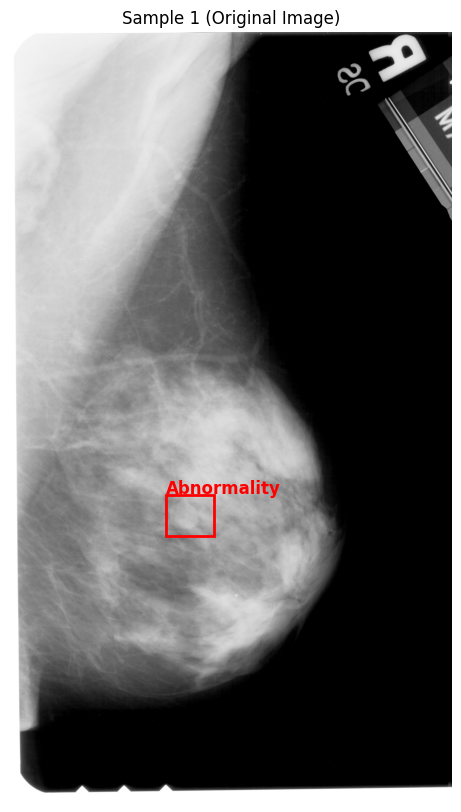

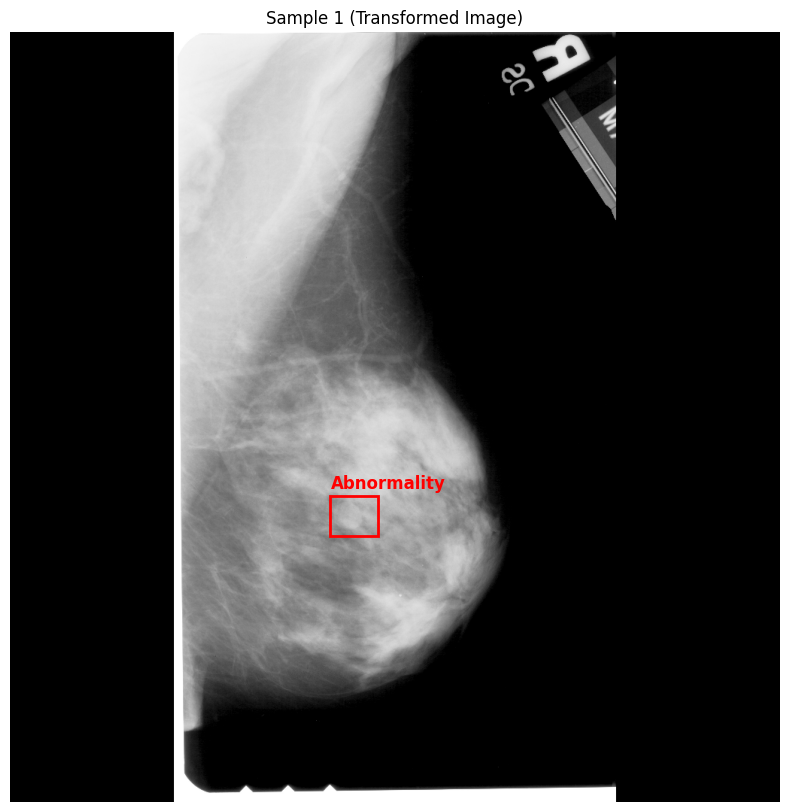

In [8]:
dataset = CBISDDSM_RCNN_Dataset(dataframe=paired_df)

transform_dataset = CBISDDSM_RCNN_Dataset(dataframe=paired_df, transform=test_transform)

check_idx = 1

dataset.visualize_sample(check_idx, title=f"Sample {check_idx} (Original Image)")

transform_dataset.visualize_sample(check_idx, title=f"Sample {check_idx} (Transformed Image)")

# Check image with multiple ROIs

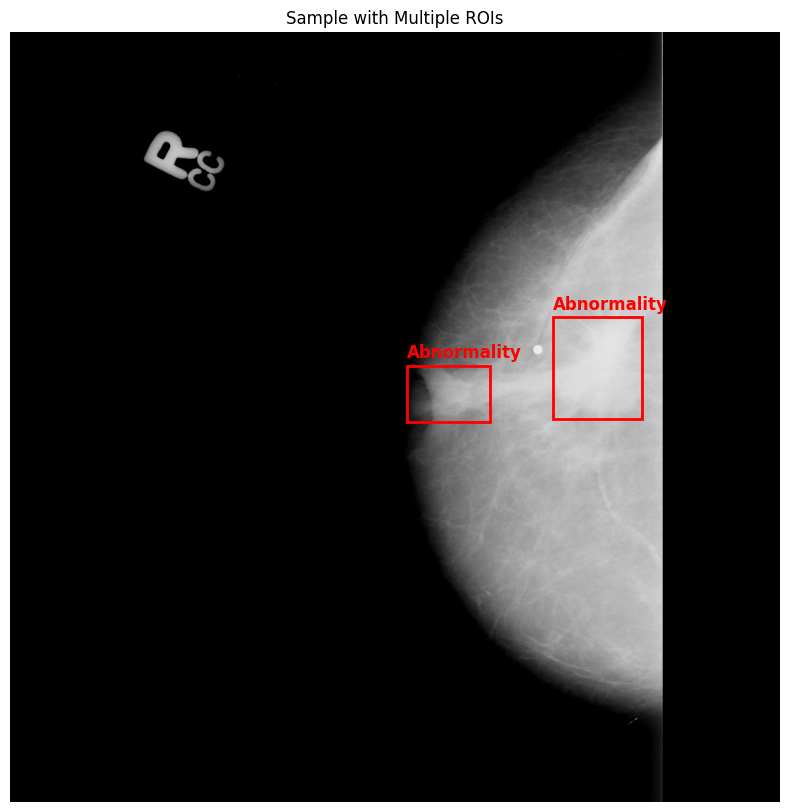

In [9]:
transform_dataset.visualize_sample(360, title=f"Sample with Multiple ROIs") # idx found through the dataset exploration notebook

# Train test split

In [22]:
# Split based on patient IDs
unique_patients = paired_df['PatientID_full'].unique()
train_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)

In [23]:
train_df = paired_df[paired_df['PatientID_full'].isin(train_patients)].copy()
test_df = paired_df[paired_df['PatientID_full'].isin(test_patients)].copy()

In [24]:
train_dataset = CBISDDSM_RCNN_Dataset(dataframe=train_df, transform=train_transform)

test_dataset = CBISDDSM_RCNN_Dataset(dataframe=test_df, transform=test_transform)

In [25]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [26]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

# Initialize model and check for cuda

In [27]:
def get_model(num_classes: int) -> FasterRCNN:
    """
    Creates and returns a Faster R-CNN object detection model based on a ResNet-50 backbone.

    The configured model uses the Faster R-CNN framework with a ResNet-50 backbone, which is pre-trained
    on the COCO dataset to initialize the weights. It modifies the box predictor to accommodate
    the specified number of classes by adapting the classification layer.

    :param num_classes: The number of classes including background class for the object detection model.
    :type num_classes: int
    :return: A Faster R-CNN model configured for the given number of classes.
    :rtype: FasterRCNN
    """

    # Base model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    )

    # Configure the model for the specified number of classes
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


num_classes = 2  # Background or abnormality
model = get_model(num_classes)

# Use CUDA if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [28]:
# Ensure the checkpoint directory exists
checkpoint_dir = '../models/Faster_RCNN/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

In [29]:
# Ensure the completed model directory exists
completed_dir = '../models/Faster_RCNN/Completed'
os.makedirs(completed_dir, exist_ok=True)

In [30]:
def get_model_file_path(prompt: str, initial_directory: str, loop: bool = True) -> str | None:
    """
    Retrieve the file path of a selected model file using a graphical file dialog. Provides a simple prompt for
    the user and allows for looping interaction until a file is selected or the process is exited.

    :param prompt: Message to display to the user in the input prompt.
    :type prompt: str
    :param initial_directory: Initial directory to open in the file dialog.
    :type initial_directory: str
    :param loop: If set to True, the function will loop until the user provides valid input.
        Defaults to True.
    :type loop: bool
    :return: The file path of the selected model file, an empty string if 'n' is chosen,
        or None if the loop is ended without selection.
    :rtype: str | None
    """

    run_once = False
    while loop and not run_once:
        run_once = True

        check = input(prompt)

        if check == 'y':
            root = tk.Tk()
            root.withdraw()
            root.attributes('-topmost', True)

            return filedialog.askopenfilename(parent=root,
                                              initialdir=initial_directory,
                                              title="Select a file",
                                              filetypes=(("Model Files", "*.pth"), ("All Files", "*.*"))
                                              )
        elif check == 'n':
            return ''
    return None


# Check for trained models

In [31]:
completed_path = None

if len(os.listdir(completed_dir)) > 0:
    completed_path = get_model_file_path("Completed model directory is not empty. Do you want to use saved model? (y/n): ",
                                         "../models/Faster_RCNN/Completed")

    if completed_path:
        print(f"Using saved model from {completed_path}")
    else:
        print("No model file selected. Starting training from scratch.")

No model file selected. Starting training from scratch.


# Check for checkpoints

In [32]:
resume_path = None

if not completed_path and len(os.listdir(checkpoint_dir)) > 0:
    resume_path = get_model_file_path("Checkpoint directory is not empty. Do you want to resume training? (y/n): ",
                                      "../models/Faster_RCNN/checkpoints")

    if resume_path:
        print(f"Resuming training from checkpoint {resume_path}")
    else:
        print("No checkpoint file selected. Starting training from scratch.")

No checkpoint file selected. Starting training from scratch.


# Train Model

In [33]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 10
start_epoch = 0

# No need for training if using an already trained model
if completed_path:
    if os.path.exists(completed_path):
        print(f"Loading model from {completed_path}")
        saved = torch.load(completed_path, map_location=device)
        model.load_state_dict(saved)
        model.eval()
        print("Model loaded successfully.")
elif resume_path:
    if os.path.exists(resume_path):
        print(f"Loading checkpoint from {resume_path}")

        # Load model from checkpoint
        checkpoint = torch.load(resume_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1

        print(f"Resuming training from epoch {start_epoch}")
    else:
        raise FileNotFoundError(f"Checkpoint file {resume_path} not found.")

if not completed_path:
    # Use autocast for mixed precision training (AMP) for faster training
    scaler = GradScaler()
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0

        for i, (images, targets) in enumerate(train_loader):
            # Move images and targets to the appropriate device (GPU if available or CPU otherwise)
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass and loss calculation
            with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', enabled=True):
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())

            # Backward pass and optimization step
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += losses.item()

            if i % 10 == 0:
                print(f"Epoch [{epoch + 1}/{num_epochs}] | Batch [{i}/{len(train_loader)}] | Loss: {losses.item():.4f}")

        lr_scheduler.step()
        print(f"--- Epoch {epoch + 1} Completed | Average Loss: {epoch_loss / len(train_loader):.4f} ---")

        # Save checkpoint
        checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_{epoch + 1}.pth')
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_loss
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")

Epoch [1/10] | Batch [0/303] | Loss: 0.6302
Epoch [1/10] | Batch [10/303] | Loss: 0.3337
Epoch [1/10] | Batch [20/303] | Loss: 0.2037
Epoch [1/10] | Batch [30/303] | Loss: 0.2698
Epoch [1/10] | Batch [40/303] | Loss: 0.2502
Epoch [1/10] | Batch [50/303] | Loss: 0.1900
Epoch [1/10] | Batch [60/303] | Loss: 0.1854
Epoch [1/10] | Batch [70/303] | Loss: 0.2504
Epoch [1/10] | Batch [80/303] | Loss: 0.1420
Epoch [1/10] | Batch [90/303] | Loss: 0.1732
Epoch [1/10] | Batch [100/303] | Loss: 0.1737
Epoch [1/10] | Batch [110/303] | Loss: 0.1764
Epoch [1/10] | Batch [120/303] | Loss: 0.1191
Epoch [1/10] | Batch [130/303] | Loss: 0.1549
Epoch [1/10] | Batch [140/303] | Loss: 0.1771
Epoch [1/10] | Batch [150/303] | Loss: 0.2599
Epoch [1/10] | Batch [160/303] | Loss: 0.1994
Epoch [1/10] | Batch [170/303] | Loss: 0.2530
Epoch [1/10] | Batch [180/303] | Loss: 0.1554
Epoch [1/10] | Batch [190/303] | Loss: 0.2110
Epoch [1/10] | Batch [200/303] | Loss: 0.1400
Epoch [1/10] | Batch [210/303] | Loss: 0.2050

In [34]:
# Save the trained model only after completing training
if not completed_path:
    model_save_path = '../models/Faster_RCNN/Completed/Completed_Training.pth'
    torch.save(model.state_dict(), model_save_path)
    print(f"Model weights saved to {model_save_path}")

Model weights saved to ../models/Faster_RCNN/Completed/Completed_Training.pth


# Visualize predicted image

In [35]:
def test_and_visualize(model: FasterRCNN, test_loader: DataLoader, device: torch.device, confidence_threshold: float = 0.2, idx: int = 0) -> None:
    """
    Test and visualize the performance of a Faster R-CNN model on a single batch of test images. The method generates
    a visualization that overlays both true bounding boxes and predicted bounding boxes onto the test image. The color
    red is used for true boxes, while green represents predicted boxes with a confidence score higher than the specified
    threshold. Predictions are annotated with their confidence scores.

    :param model: Faster R-CNN model
    :param test_loader: DataLoader object supplying a batch of test images and their corresponding ground truths
    :param device: PyTorch device specifying where the tensors should be allocated (CPU or CUDA device)
    :param confidence_threshold: Float value indicating the minimum confidence score for visualizing predicted bounding boxes
    :param idx: Index of the image in the batch to visualize
    :return: None
    """

    model.eval()

    images, targets = next(iter(test_loader))
    images = list(img.to(device) for img in images)

    # Predict bounding boxes for batch
    with torch.no_grad():
        predictions = model(images)

    # Convert image tensors to readable numpy arrays and ensure valid pixel values
    img_np = images[idx].cpu().permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)

    fig, ax = plt.subplots(1, figsize=(12, 12))

    if img_np.shape[-1] == 1:
        ax.imshow(img_np.squeeze(-1), cmap='gray')
    else:
        ax.imshow(img_np)

    # True boxes (Red)
    true_boxes = targets[idx]['boxes'].cpu().numpy()

    for box in true_boxes:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

    # Predicted boxes (Green)
    predicted_boxes = predictions[idx]['boxes'].cpu().numpy()
    predicted_scores = predictions[idx]['scores'].cpu().numpy()

    for box, score in zip(predicted_boxes, predicted_scores):
        if score >= confidence_threshold:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='g',
                                     facecolor='none')
            ax.add_patch(rect)
            plt.text(xmin, ymin, f"{score:.2f}", color='g', fontsize=12, weight='bold')
    plt.axis('off')
    plt.title("Test Image and Predictions")

    legend_elements = [Line2D([0], [0], color='r', lw=2, label='Actual'),
                       Line2D([0], [0], color='g', lw=2, label='Predicted')]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.show()

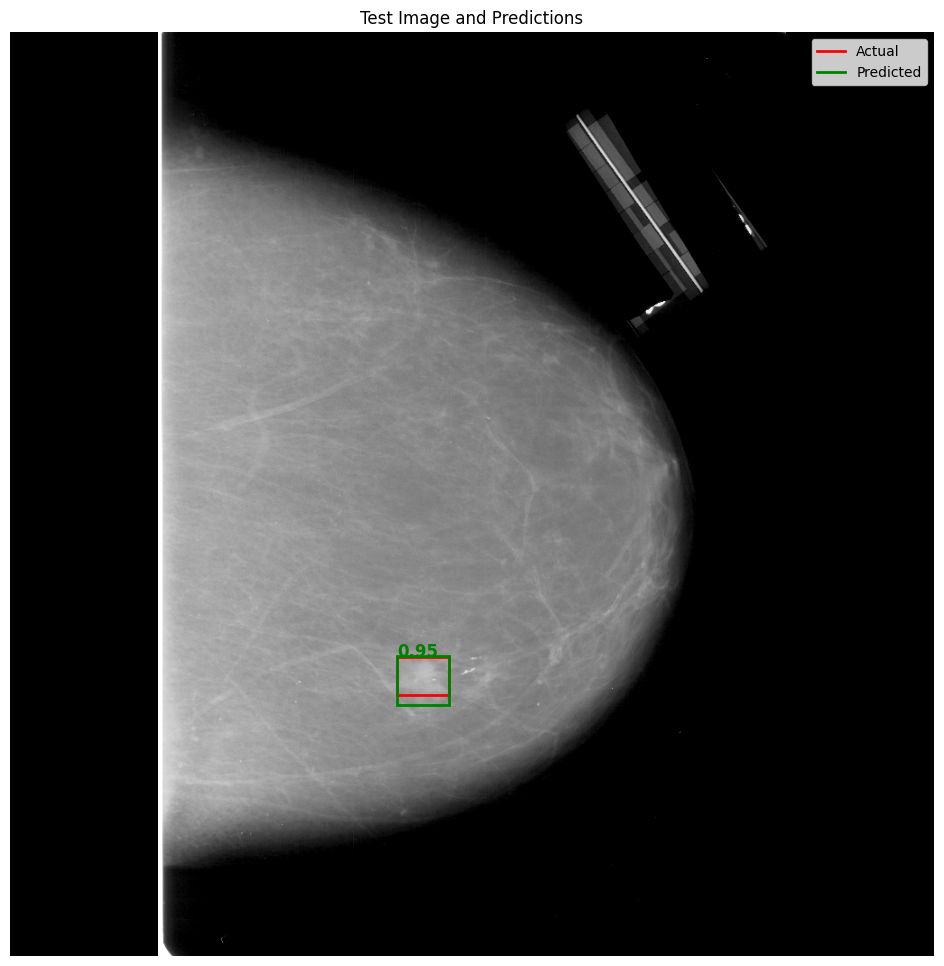

In [36]:
test_and_visualize(model, test_loader, device)

# Calculate mAP

In [37]:
def calculate_test_map(model, test_loader, device):
    print("Calculating test set mAP...")
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

    model.eval()

    print(f"Evaluating over {len(test_loader)} batches.")
    with torch.no_grad():
        for imgs, targets in tqdm(test_loader):
            imgs = list(img.to(device) for img in imgs)

            predictions = model(imgs)

            formatted_predictions = []
            for p in predictions:
                formatted_predictions.append(dict(
                    boxes=p['boxes'].cpu(),
                    scores=p['scores'].cpu(),
                    labels=p['labels'].cpu()
                ))

            formatted_targets = []
            for t in targets:
                formatted_targets.append(dict(
                    boxes=t['boxes'].cpu(),
                    labels=t['labels'].cpu()
                ))

            metric.update(formatted_predictions, formatted_targets)

    print("Computing final mAP...")
    results = metric.compute()
    print("Done")

    return results

In [38]:
map_results = calculate_test_map(model, test_loader, device)

Calculating test set mAP...
Evaluating over 76 batches.


100%|██████████| 76/76 [03:09<00:00,  2.50s/it]


Computing final mAP...
Done


In [39]:
print(f"mAP @ IoU=0.50:0.95 (COCO Standard): {map_results['map'].item():.4f}")
print(f"mAP @ IoU=0.50 (PASCAL VOC Standard): {map_results['map_50'].item():.4f}")

mAP @ IoU=0.50:0.95 (COCO Standard): 0.2680
mAP @ IoU=0.50 (PASCAL VOC Standard): 0.6172
